## First Steps: Import all libreries required

In [6]:
import fastf1 as f1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('Pandas version: ',pd.__version__)
print('Numpy version: ',np.__version__)
print('Seaborn version: ',sns.__version__)
print('Fastf1 version: ',f1.__version__)


Pandas version:  2.3.3
Numpy version:  2.4.3
Seaborn version:  0.13.2
Fastf1 version:  3.8.1


## Declaration of the development environment

In [7]:
import sys, random, platform

RANDOM_SEED = 414

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print('Platform:', platform.platform())
print(f'Python  : {sys.version.split()[0]}')

Platform: Linux-6.19.7-1-cachyos-x86_64-with-glibc2.42
Python  : 3.13.11


## Import relevant data

In [8]:
years, results = [2022,2023,2024], []

for i in years:
    
    schedule = f1.get_event_schedule(i)
    
    for race in schedule['EventName']:
        
        try:
            session = f1.get_session(i, race, 'R')
            session.load(laps=False, telemetry=False, weather=False)
            res = session.results
            res['year'], res['race'] = i, race
            results.append(res)
        
        except:
            pass

df = pd.concat(results)

events      WARNING 	Correcting user input 'Pre-Season Track Session' to 'British Grand Prix'
core           INFO 	Loading data for British Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['55', '11', '44', '16', '14', '4', '1', '47', '5', '20', '18', '6', '3', '22', '31', '10', '77', '63', '24', '23']
events      WARNING 	Correcting user input 'Pre-Season Test' to 'United States Grand Prix'
core           INFO 	Loading data for United States Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '44', '16', '11', '63', '4', '14', '5', '20', '22', '31', '24', '23', '

## A brief look at the data

In [15]:
display(df.head(5))
columns = [x for x in df.columns]
print('DataFrame Shape: ',df.shape)
print('DataFrame Columns: ', columns)

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,GridPosition,Q1,Q2,Q3,Time,Status,Points,Laps,year,race
55,55,C SAINZ,SAI,sainz,Ferrari,ed1c24,ferrari,Carlos,Sainz,Carlos Sainz,...,1.0,NaT,NaT,NaT,0 days 02:17:50.311000,Finished,25.0,52.0,2022,Pre-Season Track Session
11,11,S PEREZ,PER,perez,Red Bull Racing,1e5bc6,red_bull,Sergio,Perez,Sergio Perez,...,4.0,NaT,NaT,NaT,0 days 00:00:03.779000,Finished,18.0,52.0,2022,Pre-Season Track Session
44,44,L HAMILTON,HAM,hamilton,Mercedes,6cd3bf,mercedes,Lewis,Hamilton,Lewis Hamilton,...,5.0,NaT,NaT,NaT,0 days 00:00:06.225000,Finished,16.0,52.0,2022,Pre-Season Track Session
16,16,C LECLERC,LEC,leclerc,Ferrari,ed1c24,ferrari,Charles,Leclerc,Charles Leclerc,...,3.0,NaT,NaT,NaT,0 days 00:00:08.546000,Finished,12.0,52.0,2022,Pre-Season Track Session
14,14,F ALONSO,ALO,alonso,Alpine,2293d1,alpine,Fernando,Alonso,Fernando Alonso,...,7.0,NaT,NaT,NaT,0 days 00:00:09.571000,Finished,10.0,52.0,2022,Pre-Season Track Session


DataFrame Shape:  (1439, 24)
DataFrame Columns:  ['DriverNumber', 'BroadcastName', 'Abbreviation', 'DriverId', 'TeamName', 'TeamColor', 'TeamId', 'FirstName', 'LastName', 'FullName', 'HeadshotUrl', 'CountryCode', 'Position', 'ClassifiedPosition', 'GridPosition', 'Q1', 'Q2', 'Q3', 'Time', 'Status', 'Points', 'Laps', 'year', 'race']


### Question 1: Is the dataset balanced between Top-10 and non-Top-10 finishes?

/tmp/ipykernel_2067/309186928.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='top_10', data=df, palette=['#A10000', '#00AD18'])


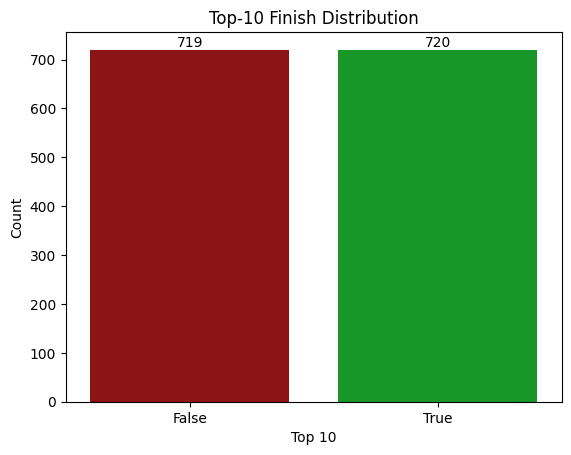

In [ ]:
# PLOT 1: Top-10 Finish Distribution

df['top_10'] = df['Position'] <= 10

ax = sns.countplot(x='top_10', data=df, palette=['#A10000', '#00AD18'])

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top-10 Finish Distribution")
plt.xlabel("Top 10")
plt.ylabel("Count")

plt.show()

### Interpretation:

Arround 50% of drivers finish in the Top-10, and 50% finish outside oof this group.
This is expected because each race has around 20 drivers and exactly 10 Top-10 positions.\

### Decision:

Given that the set of drivers finishing in the top 10 is balanced, a benchmark model that consistently predicts a class would achieve an accuracy of around 50%.
Therefore, any predictive model must significantly exceed this threshold to provide useful predictions, as half of the data meets the condition.

